In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np

import os
import sys

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from plotnine import *
from tqdm import tqdm
from scipy.stats import anderson_ksamp, false_discovery_control

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging

os.chdir("/g/stegle/schrod/code/TCell")
from utils import *

logging.basicConfig(format="[%(asctime)s] %(levelname)s:%(name)s: %(message)s", stream=sys.stdout)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


def qq_plot(p_values_dict, title=None, cutoff=None, samples = None, save_path=None):
    """
    Draws a combined QQ plot for multiple datasets.
    
    Parameters
    ----------
    p_values_dict : dict
        Dictionary with dataset names as keys and p-value arrays as values.
    title : str
        Plot title.
    """
    plt.figure(figsize=(8, 8))
    
    colors = ['steelblue', 'coral', 'seagreen', 'purple']
    markers = ['o', 's', '^', 'D']
    
    max_expected = 0
    
    for i, (name, p_values) in enumerate(p_values_dict.items()):
        if samples is not None:
            p_values = np.random.choice(p_values, size=samples, replace=False)
        p_values = np.array(p_values)
        p_values = p_values[~np.isnan(p_values)]  # remove NaNs
        p_values = p_values[(p_values > 0) & (p_values <= 1)]  # valid range
        
        if len(p_values) == 0:
            logger.warning(f"No valid p-values for {name}")
            continue
        
        # Expected quantiles under uniform(0,1) null
        n = len(p_values)
        expected = -np.log10(np.linspace(1/(n+1), n/(n+1), n))
        
        # Observed quantiles
        observed = -np.log10(np.sort(p_values))
        
        if cutoff is not None:
            observed[observed > cutoff] = cutoff
   
        
        # Plot with different colors and markers
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        plt.scatter(expected, observed, s=15, edgecolor='none', alpha=0.6, 
                   color=color, marker=marker, label=f'{name} (n={len(p_values):,})')
        
        max_expected = max(max_expected, max(expected))
    
    # y=x line
    plt.plot([0, max_expected], [0, max_expected], color='red', linestyle='--', 
            linewidth=2, label='Expected (uniform)')
    
    plt.xlabel("Expected -log10(p)", fontsize=12)
    plt.ylabel("Observed -log10(p)", fontsize=12)
    if title is not None:
        plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(loc='upper left', fontsize=10)
    if cutoff is not None:
        plt.xlim(0, cutoff)
        plt.ylim(0, cutoff)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
        logger.info(f"Saved QQ plot to {save_path}")
    plt.show()


In [17]:
DEG_results_path_pb = "/g/stegle/schrod/code/TCell/wilcoxon_batch_calibration_NT"
logger.info(f"Load pseudobulk Wilcoxon results from: {DEG_results_path_pb}")
df_nt = load_deg_results(DEG_results_path_pb, pval_threshold=None)  


[2026-02-16 18:18:48,326] INFO:__main__: Load pseudobulk Wilcoxon results from: /g/stegle/schrod/code/TCell/wilcoxon_batch_calibration_NT


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 297/297 [00:02<00:00, 111.11it/s]


In [18]:
df_nt_sig = df_nt[df_nt["pvals_adj"] < 0.1].copy()
print("Number of significant hits (pval<0.1):", df_nt_sig.shape[0])
print("total number of tests:", df_nt.shape[0])
print(f"Fraction of significant hits: {df_nt_sig.shape[0] / df_nt.shape[0]:.4f}")
df_nt_sig.names.value_counts()


Number of significant hits (pval<0.1): 10
total number of tests: 2335500
Fraction of significant hits: 0.0000


names
SLC41A2    1
ZNF688     1
MGAT2      1
YES1       1
BRIX1      1
G3BP1      1
NOL10      1
DUT        1
DCTPP1     1
BANF1      1
Name: count, dtype: int64

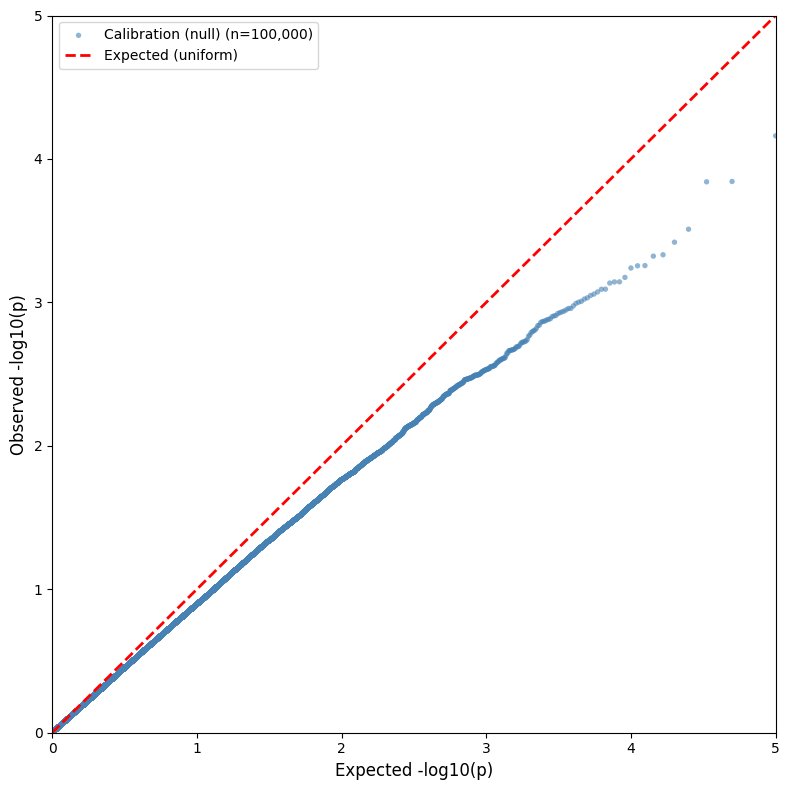

In [19]:
qq_plot({'Calibration (null)': df_nt['pvals'].values}, cutoff=5, samples = 100000)

In [ ]:

DEG_results_path = "/g/stegle/schrod/code/TCell/results_pseudobulk/DEG_bulk_rerun"
logger.info(f"Load bulked Wilcoxon results from: {DEG_results_path}")
df_wilcoxon = load_deg_results(DEG_results_path, pval_threshold=None)  

[2026-02-16 18:12:57,955] INFO:__main__: Load bulked Wilcoxon results from: /g/stegle/schrod/code/TCell/results_pseudobulk/DEG_bulk_rerun


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.33s/it]


In [ ]:
df_wilcoxon_sig = df_wilcoxon[df_wilcoxon["pvals_adj"] < 0.1].copy()
print("Number of significant hits (pval<0.1):", df_wilcoxon_sig.shape[0])
print("total number of tests:", df_wilcoxon.shape[0])
print(f"Fraction of significant hits: {df_wilcoxon_sig.shape[0] / df_wilcoxon.shape[0]:.4f}")
df_wilcoxon_sig.names.value_counts()

Number of significant hits (pval<0.1): 6319
total number of tests: 38652871
Fraction of significant hits: 0.0002


names
FABP5       9
HSP90AB1    9
RPL22L1     8
NOLC1       8
HMGA1       7
           ..
APOLD1      1
BDH2        1
CAT         1
CAMK4       1
PAPSS1      1
Name: count, Length: 3920, dtype: int64

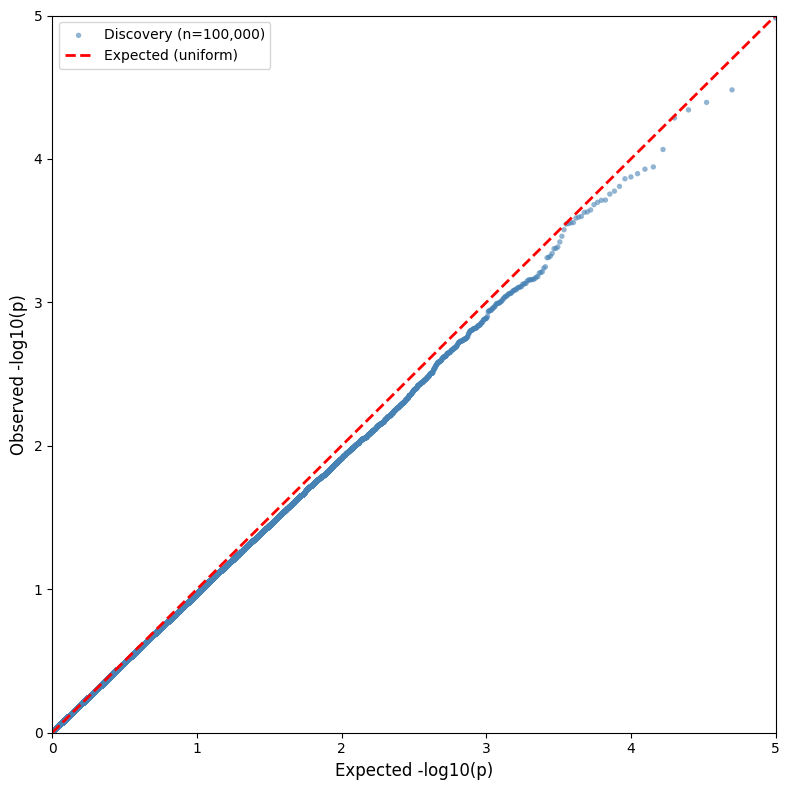

In [ ]:
# subsample to 1000000 points for better visualization
df_wilcoxon_sub = df_wilcoxon.sample(n=1000000, random_state=42)
qq_plot({'Discovery': df_wilcoxon_sub['pvals'].values}, cutoff=5, samples = 100000)


[2026-02-16 18:19:25,677] INFO:__main__: Saved QQ plot to /g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf


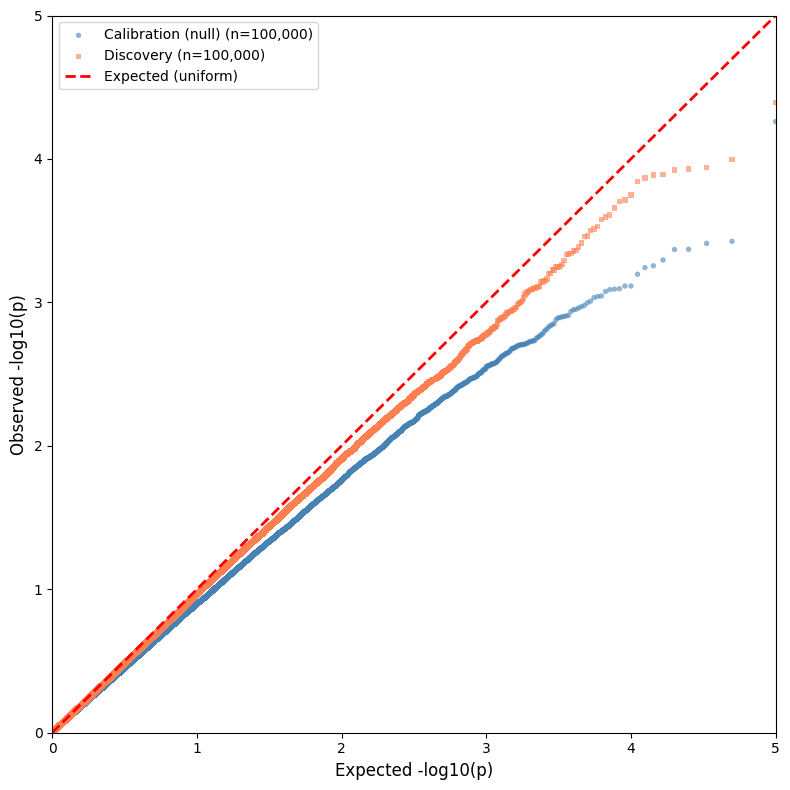

In [ ]:



p_values_dict = {
    'Calibration (null)': df_nt['pvals'].values,
    'Discovery': df_wilcoxon_sub['pvals'].values
}
np.random.seed(42)
qq_plot(p_values_dict, cutoff=5, samples = 100000, save_path="/g/stegle/schrod/code/TCell/plots/final/QQ_plot_NT_calibration_vs_discovery.pdf")
